# Trader Behavior Analysis Based on Bitcoin Market Sentiment

## Objective
This project analyzes the relationship between trader performance and Bitcoin market sentiment using the Fear & Greed Index and historical trader data. The goal is to identify patterns between market sentiment and trading profitability.

## Dataset Description

Two datasets were used in this analysis:

1. Fear & Greed Index Dataset – Contains daily Bitcoin market sentiment classified as Fear, Greed, Neutral, and Extreme Greed.

2. Historical Trader Dataset – Contains trading activity such as account address, execution price, trade size, trade side, timestamp, and closed profit/loss.

Both datasets were merged based on the trading date to analyze trader performance under different market sentiment conditions.

## Key Insights

1. Traders achieve the highest average profit during Greed market sentiment.

2. Fear sentiment has the highest number of trades, indicating increased activity during uncertain markets.

3. Extreme Greed markets show lower profitability, suggesting traders may enter positions late during strong bullish trends.

4. Neutral markets produce the lowest average profit due to lower volatility.

Cell 1 — Import Libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Cell 2 — Load Datasets

In [7]:
sentiment = pd.read_csv("fear_greed_index.csv")

trades = pd.read_csv(
    "historical_data.csv",
    on_bad_lines="skip",
    low_memory=False
)

Cell 3 — Convert Date Columns

In [6]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

trades["Timestamp"] = pd.to_datetime(trades["Timestamp"], unit="ms", errors="coerce")

Cell 4 — Convert Numeric Columns

In [8]:
trades["Closed PnL"] = pd.to_numeric(trades["Closed PnL"], errors="coerce")
trades["Size USD"] = pd.to_numeric(trades["Size USD"], errors="coerce")
trades["Execution Price"] = pd.to_numeric(trades["Execution Price"], errors="coerce")

Cell 5 — Remove Invalid Rows

In [9]:
trades = trades.dropna(subset=["Closed PnL"])

Cell 6 — Extract Date

In [11]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

trades["Timestamp"] = pd.to_datetime(trades["Timestamp"], unit="ms", errors="coerce")

Cell 7 — Merge Datasets

In [13]:
trades["date"] = trades["Timestamp"].dt.date
sentiment["date_only"] = sentiment["date"].dt.date
merged = trades.merge(
    sentiment[["date_only", "classification", "value"]],
    left_on="date",
    right_on="date_only",
    how="left"
)

Cell 8 — Dataset Information

In [14]:
print("Sentiment dataset shape:", sentiment.shape)
print("Trades dataset shape:", trades.shape)

Sentiment dataset shape: (2644, 5)
Trades dataset shape: (329226, 17)


Cell 9 — Trader Performance Analysis

In [15]:
performance = merged.groupby("classification")["Closed PnL"].mean()

print("Average Trader Profit by Market Sentiment:")
print(performance)

Average Trader Profit by Market Sentiment:
classification
Extreme Greed    25.418722
Fear             40.811896
Greed            76.483698
Neutral          12.291732
Name: Closed PnL, dtype: float64


Cell 10 — Trade Count by Sentiment

In [16]:
trade_counts = merged["classification"].value_counts()

print("Number of Trades by Market Sentiment:")
print(trade_counts)

Number of Trades by Market Sentiment:
classification
Fear             208166
Greed             61071
Neutral           10992
Extreme Greed      6962
Name: count, dtype: int64


Cell 11 — Top Traders

In [17]:
top_traders = merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

print("Top 10 Traders by Profit:")
print(top_traders)

Top 10 Traders by Profit:
Account
0xbaaaf6571ab7d575                            1.740000e+12
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    8.086157e+10
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    7.796161e+10
0xb899e522b5715391ae1d4f137653e7906c5e2115    7.438480e+10
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143309e+06
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    1.672134e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    1.355222e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401278e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    8.526516e+05
Name: Closed PnL, dtype: float64


Cell 12 — Graph: Profit Distribution

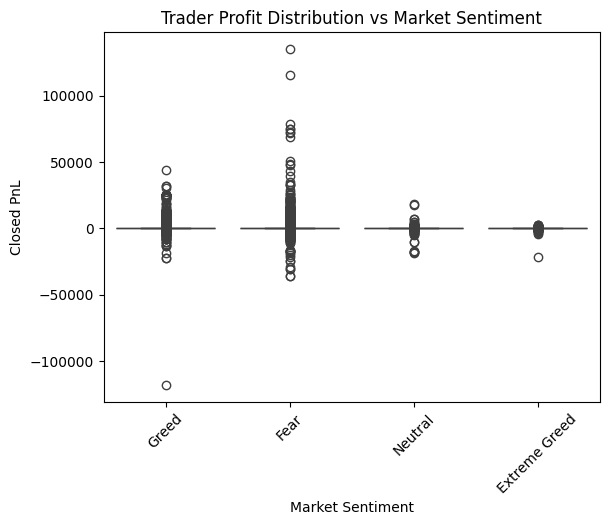

In [18]:
plt.figure()
sns.boxplot(x="classification", y="Closed PnL", data=merged)

plt.title("Trader Profit Distribution vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.xticks(rotation=45)
plt.show()

Cell 13 — Graph: Trade Count

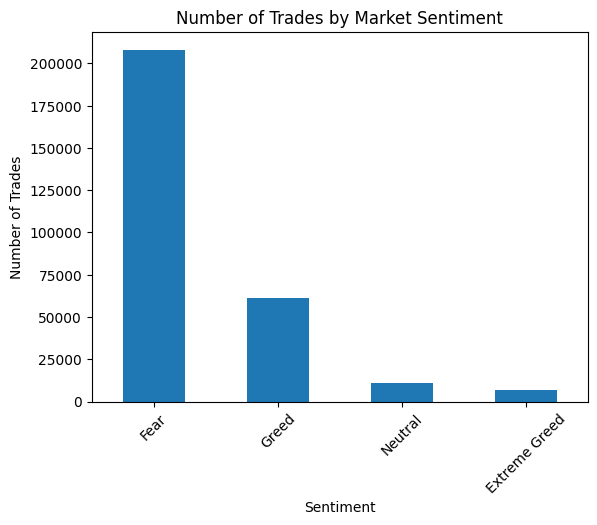

In [19]:
plt.figure()

trade_counts.plot(kind="bar")

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)
plt.show()

Cell 14 — Graph: Average Profit

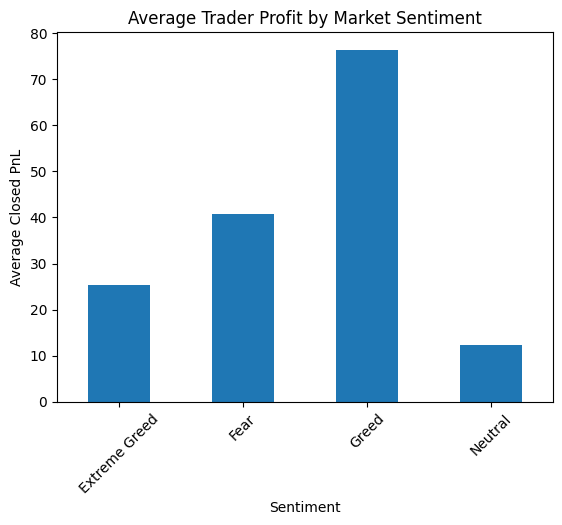

In [20]:
plt.figure()

performance.plot(kind="bar")

plt.title("Average Trader Profit by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)
plt.show()

Cell 15 — Completion Message

In [21]:
print("Analysis Completed Successfully ✅")

Analysis Completed Successfully ✅
